# Fault-tolerant circuit extraction from a handwritten stabilizer-state sketch

This notebook turns the supplied sketch into an executable Stim preparation circuit while keeping the two synthesis concerns separate:

```text
handwritten topology
        ↓  explicit transcription
stabilizer state
        ↓
Module A — state → verified noisy trivalent ZX diagram
        ║  typed, validated diagram handoff
Module B — cubic ZX diagram → resource-aware Stim circuit
        ↓
state, detector, and resource checks
```

The JPEG is **not** treated as an automatically parsed graph. Its topology is transcribed explicitly below, so every ambiguity and assumption is visible and editable. The fault-tolerance claim made here is also deliberately scoped: each SpiderCat replacement is exactly checked for marked-cut robustness at \(t=1\), and Module B applies the repository's fixed fault-equivalent ZX-to-circuit rewrites. This notebook is not a threshold estimate or a separate exhaustive enumeration of every gate-level fault.

In [1]:
from collections import Counter
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import stim
from IPython.display import Image, Markdown, SVG, display


def find_repository_root(start: Path) -> Path:
    # Locate the repository whether the notebook starts at root or notebooks/.
    for candidate in (start, *start.parents):
        if (candidate / "spiderstate").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("Could not locate the spidercat repository root.")


REPO_ROOT = find_repository_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from spiderstate import (
    LCSearchConfig,
    normalize_zx_diagram,
    synthesize_stabilizer_state,
    synthesize_zx,
)
from spiderstate.spidercat_gadgets import verify_t_robustness
from spiderstate.zx_ir import EdgeRole, FaultStatus, NodeKind

SKETCH_PATH = REPO_ROOT / "notebooks" / "assets" / "five_qubit_ft_extraction_sketch.jpeg"
OUTPUT_DIR = REPO_ROOT / "output" / "circuits"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert SKETCH_PATH.exists(), SKETCH_PATH
print(f"repository: {REPO_ROOT}")
print(f"input image: {SKETCH_PATH.relative_to(REPO_ROOT)}")

repository: /Users/sarahli/Desktop/spidercat
input image: notebooks/assets/five_qubit_ft_extraction_sketch.jpeg


## 1. Read and transcribe the sketch

The drawing most naturally reads as:

- five white five-vertex cycles: five arity-5 Z-SpiderCat gadgets;
- five blue crossed four-vertex blocks: five Lemma B* \(K_{2,2}\) replacements, one for each original graph edge;
- five long black legs: five output qubits;
- the long closing arcs on the right: the edge that closes a five-cycle.

That determines a topology, but not a unique quantum state: colours, phases, signs, port order, \(t\), and possible output Clifford boxes are not written on the page. We therefore make the literal phase-free choice: all five logical vertices are Z spiders and the pre-expansion state is the labelled \(C_5\) graph state.

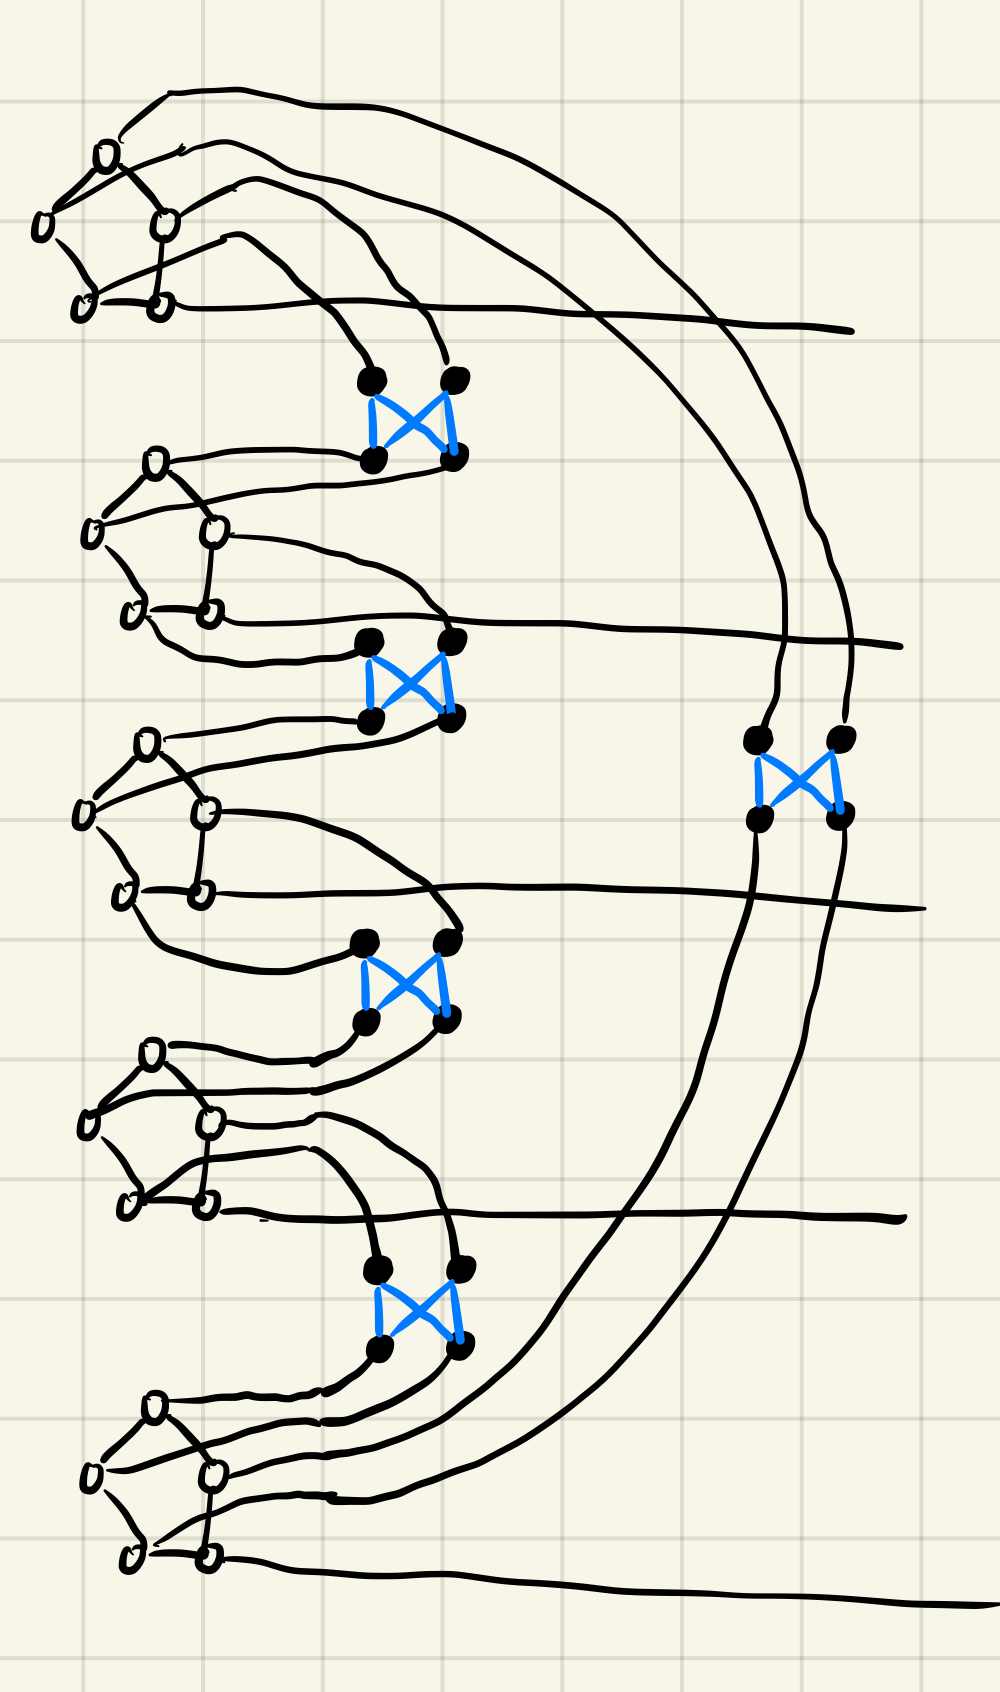

In [2]:
display(Image(filename=str(SKETCH_PATH), width=470))

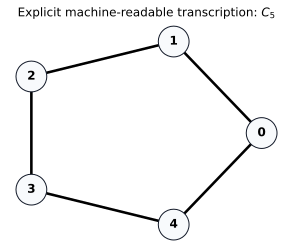

| qubit | neighbours | graph-state generator |
|---:|:---:|:---|
| 0 | 1, 4 | `XZIIZ` |
| 1 | 0, 2 | `ZXZII` |
| 2 | 1, 3 | `IZXZI` |
| 3 | 2, 4 | `IIZXZ` |
| 4 | 0, 3 | `ZIIZX` |

In [3]:
# This is the only manually supplied semantic transcription.
CYCLE_EDGES = ((0, 1), (1, 2), (2, 3), (3, 4), (4, 0))
TARGET_STABILIZERS = (
    "XZIIZ",  # K_0 = X_0 Z_1 Z_4
    "ZXZII",  # K_1 = Z_0 X_1 Z_2
    "IZXZI",  # K_2 = Z_1 X_2 Z_3
    "IIZXZ",  # K_3 = Z_2 X_3 Z_4
    "ZIIZX",  # K_4 = Z_3 X_4 Z_0
)
REQUESTED_T = 1

transcribed_graph = nx.Graph()
transcribed_graph.add_nodes_from(range(5))
transcribed_graph.add_edges_from(CYCLE_EDGES)

fig, ax = plt.subplots(figsize=(5.0, 4.0))
pos = nx.circular_layout(transcribed_graph)
nx.draw_networkx(
    transcribed_graph,
    pos=pos,
    ax=ax,
    node_color="#f8fafc",
    edgecolors="#111827",
    node_size=950,
    width=2.6,
    font_weight="bold",
)
ax.set_title("Explicit machine-readable transcription: $C_5$")
ax.axis("off")
plt.show()

rows = ["| qubit | neighbours | graph-state generator |", "|---:|:---:|:---|"]
for qubit, stabilizer in enumerate(TARGET_STABILIZERS):
    neighbours = ", ".join(map(str, sorted(transcribed_graph.neighbors(qubit))))
    rows.append(f"| {qubit} | {neighbours} | `{stabilizer}` |")
display(Markdown("\n".join(rows)))

## 2. Module A — fault-tolerant state decomposition

`synthesize_stabilizer_state` owns all state-level decisions. It validates the stabilizers, obtains a graph-state representative, applies Lemma B*, replaces every high-arity spider by a verified SpiderCat gadget, and returns three immutable-by-convention snapshots plus provenance.

For this literal transcription we disable local-complementation optimization. That preserves the labelled \(C_5\) drawn above and ensures no unshown boundary Clifford corrections are introduced.

In [4]:
decomposition = synthesize_stabilizer_state(
    TARGET_STABILIZERS,
    t=REQUESTED_T,
    lc_search=LCSearchConfig(optimize=False),
)

assert set(map(frozenset, decomposition.graph.edges())) == set(map(frozenset, CYCLE_EDGES))
assert decomposition.graph_conversion.validate_certificate()
assert not decomposition.final_diagram.nodes_of_kind(NodeKind.LOCAL_CLIFFORD)

summary = {
    "input qubits": len(TARGET_STABILIZERS),
    "graph edges": decomposition.graph.number_of_edges(),
    "LC search mode": decomposition.search_metadata.mode,
    "requested t": decomposition.guarantee_metadata.requested_t,
    "diagram guarantee": decomposition.guarantee_metadata.status,
    "SpiderCat replacements": decomposition.guarantee_metadata.construction_count,
}
display(Markdown("\n".join(f"- **{key}:** `{value}`" for key, value in summary.items())))

- **input qubits:** `5`
- **graph edges:** `5`
- **LC search mode:** `disabled`
- **requested t:** `1`
- **diagram guarantee:** `verified`
- **SpiderCat replacements:** `5`

### Ideal graph-state diagram

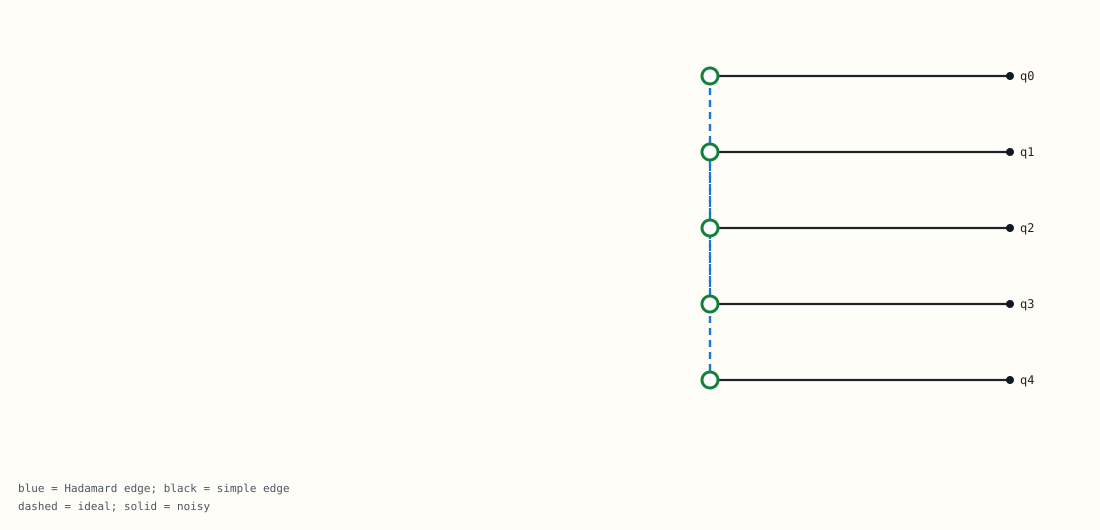

### After Lemma B*

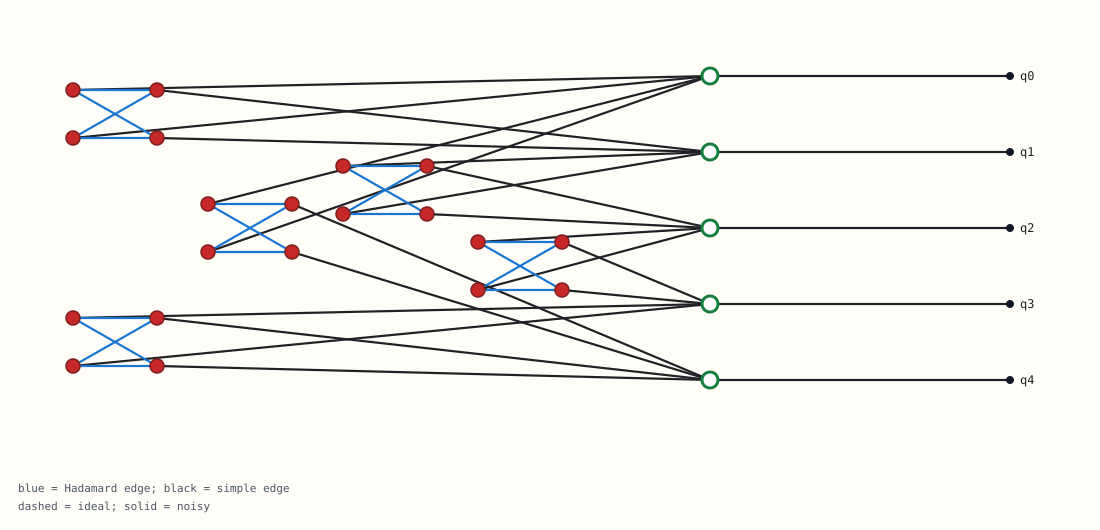

### Final noisy trivalent diagram

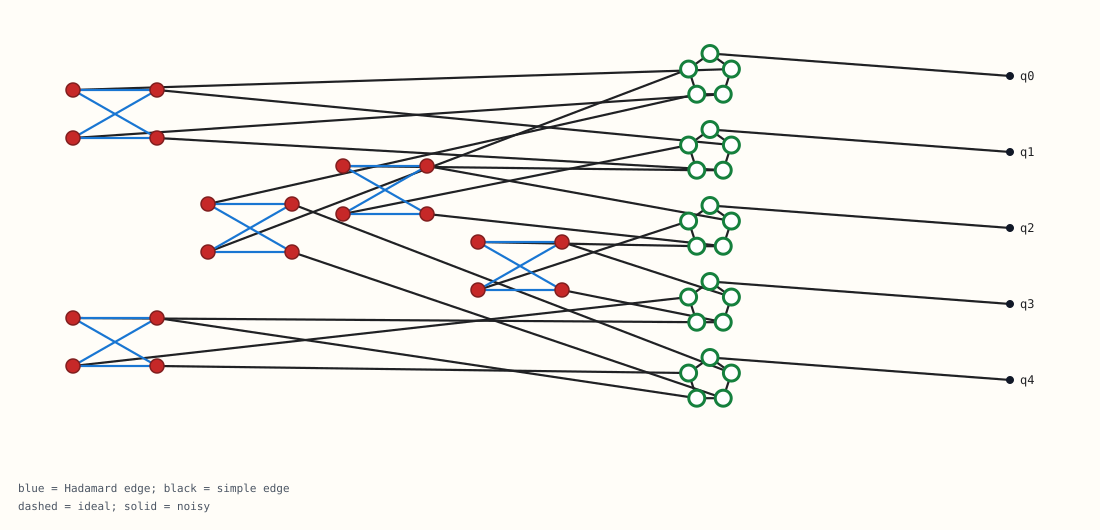

In [5]:
for heading, stage in (
    ("Ideal graph-state diagram", "ideal"),
    ("After Lemma B*", "lemma_b_star"),
    ("Final noisy trivalent diagram", "final"),
):
    display(Markdown(f"### {heading}"))
    display(SVG(decomposition.render_svg(stage)))

### Structural and fault-tolerance certificate

The sketch predicts 25 Z spiders and 20 X spiders. The following cell checks that structure directly, verifies that every internal wire is marked noisy with provenance, and reruns the exact marked-cut robustness test on each of the five replacement gadgets.

In [6]:
final_diagram = decomposition.final_diagram
kind_counts = Counter(
    data["kind"] for _, data in final_diagram.graph.nodes(data=True)
)
internal_spiders = [
    node
    for node, data in final_diagram.graph.nodes(data=True)
    if data["kind"] in (NodeKind.Z_SPIDER, NodeKind.X_SPIDER)
]

structural_checks = {
    "outputs = 5": len(final_diagram.nodes_of_kind(NodeKind.BOUNDARY)) == 5,
    "Z spiders = 25": kind_counts[NodeKind.Z_SPIDER] == 25,
    "X spiders = 20": kind_counts[NodeKind.X_SPIDER] == 20,
    "internal spiders = 45": len(internal_spiders) == 45,
    "maximum spider degree = 3": max(final_diagram.graph.degree(v) for v in internal_spiders) == 3,
    "no original ideal graph edges remain": not final_diagram.edges_of_role(EdgeRole.GRAPH_EDGE),
    "all internal edges are noisy": all(
        data["fault_status"] is FaultStatus.NOISY
        for _, _, data in final_diagram.internal_edges()
    ),
    "all nodes carry provenance": all(
        data.get("provenance") is not None
        for _, data in final_diagram.graph.nodes(data=True)
    ),
    "all edges carry provenance": all(
        data.get("provenance") is not None
        for _, _, data in final_diagram.graph.edges(data=True)
    ),
}
assert all(structural_checks.values()), structural_checks

check_rows = ["| invariant | result |", "|:---|:---:|"]
check_rows.extend(
    f"| {name} | {'PASS' if passed else 'FAIL'} |"
    for name, passed in structural_checks.items()
)
display(Markdown("\n".join(check_rows)))

gadget_rows = [
    "| source spider | construction | arity | gadget vertices | ports | exact t=1 check |",
    "|:---|:---|---:|---:|---:|:---:|",
]
for replacement in decomposition.gadget_metadata.replacements:
    gadget = final_diagram.graph.subgraph(replacement.gadget_nodes).copy()
    robust = verify_t_robustness(gadget, REQUESTED_T)
    assert robust
    gadget_rows.append(
        f"| `{replacement.source_node}` | `{replacement.construction}` | "
        f"{replacement.arity} | {len(replacement.gadget_nodes)} | "
        f"{len(replacement.ports)} | PASS |"
    )
display(Markdown("\n".join(gadget_rows)))

| invariant | result |
|:---|:---:|
| outputs = 5 | PASS |
| Z spiders = 25 | PASS |
| X spiders = 20 | PASS |
| internal spiders = 45 | PASS |
| maximum spider degree = 3 | PASS |
| no original ideal graph edges remain | PASS |
| all internal edges are noisy | PASS |
| all nodes carry provenance | PASS |
| all edges carry provenance | PASS |

| source spider | construction | arity | gadget vertices | ports | exact t=1 check |
|:---|:---|---:|---:|---:|:---:|
| `z:q0` | `verified-cycle-5` | 5 | 5 | 5 | PASS |
| `z:q1` | `verified-cycle-5` | 5 | 5 | 5 | PASS |
| `z:q2` | `verified-cycle-5` | 5 | 5 | 5 | PASS |
| `z:q3` | `verified-cycle-5` | 5 | 5 | 5 | PASS |
| `z:q4` | `verified-cycle-5` | 5 | 5 | 5 | PASS |

## 3. Typed handoff between the modules

Module A stops at `final_diagram`. The handoff below is intentionally narrow:

1. validate the project-owned annotated ZX representation;
2. convert it to PyZX without changing Module A;
3. normalize it against Module B's phase-free, cubic input contract.

The assertions make the seam executable documentation. Extraction never needs the original stabilizer generators or Module A's search internals.

In [7]:
final_diagram.validate()
extraction_input = final_diagram.to_pyzx()
normalized = normalize_zx_diagram(extraction_input)

assert len(normalized.outputs) == 5
assert len(normalized.spiders) == 45
assert all(
    len(normalized.incident_edges[spider]) == 3
    for spider in normalized.spiders
)

print("Module-B handoff accepted")
print(f"  vertices: {len(normalized.original_vertices)}")
print(f"  cubic spiders: {len(normalized.spiders)}")
print(f"  edges: {len(normalized.edges)}")
print(f"  outputs: {len(normalized.outputs)}")

Module-B handoff accepted
  vertices: 50
  cubic spiders: 45
  edges: 70
  outputs: 5


## 4. Module B — resource-aware circuit extraction

Both extraction policies use the same fixed fault-equivalent local rewrite catalogue. Only layout, half-edge roles, scheduling, and physical-qubit reuse differ:

- `gate_count` lexicographically minimizes CX count first and tends to reuse qubits;
- `depth` prioritizes total depth and CX depth, usually spending more qubits.

The heuristic is seeded, so the notebook is deterministic and fast to rerun.

In [8]:
extractions = {
    strategy: synthesize_zx(
        extraction_input,
        strategy=strategy,
        optimizer="heuristic",
        seed=5,
    )
    for strategy in ("gate_count", "depth")
}

resource_rows = [
    "| strategy | CX | H | prep. | meas. | feedback | detectors | depth | CX depth | qubits | optimizer |",
    "|:---|---:|---:|---:|---:|---:|---:|---:|---:|---:|:---|",
]
for strategy, result in extractions.items():
    metrics = result.metrics
    resource_rows.append(
        f"| `{strategy}` | {metrics.cx_count} | {metrics.h_count} | "
        f"{metrics.preparation_count} | {metrics.measurement_count} | "
        f"{metrics.feedback_count} | {metrics.detector_count} | "
        f"{metrics.depth} | {metrics.cx_depth} | {metrics.num_qubits} | "
        f"`{result.optimizer_status}` |"
    )
display(Markdown("\n".join(resource_rows)))

| strategy | CX | H | prep. | meas. | feedback | detectors | depth | CX depth | qubits | optimizer |
|:---|---:|---:|---:|---:|---:|---:|---:|---:|---:|:---|
| `gate_count` | 155 | 272 | 135 | 130 | 255 | 15 | 365 | 116 | 32 | `heuristic_requested+reused` |
| `depth` | 155 | 284 | 135 | 130 | 266 | 15 | 112 | 36 | 135 | `heuristic_requested+parallel` |

In [9]:
# Keep the lower-width, gate-count-oriented realization as the deliverable.
selected = extractions["gate_count"]
stim_path = OUTPUT_DIR / "five_cycle_graph_state_t1.stim"
selected.to_file(str(stim_path))

output_qubits = [
    selected.output_qubits[boundary]
    for boundary in extraction_input.outputs()
]
assert len(set(output_qubits)) == 5

circuit_lines = str(selected.circuit).splitlines()
preview_lines = 42
print("\n".join(circuit_lines[:preview_lines]))
if len(circuit_lines) > preview_lines:
    print(f"\n... {len(circuit_lines) - preview_lines} more lines ...")
print(f"\nSaved complete circuit to: {stim_path.relative_to(REPO_ROOT)}")
print(f"Logical outputs q0..q4 occupy physical qubits: {output_qubits}")

RX 2
R 5 6
RX 1
R 7 8
RX 3
R 9 10
RX 0
R 11 12
RX 4
R 13 14
RX 15
R 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31
TICK
CX 2 5 1 7 3 9 0 11 4 13 15 16
TICK
CX 2 6 1 8 3 10 0 12 4 14 15 17
TICK
CX 6 16
TICK
MX 6
M 16
TICK
H 2
CX rec[-1] 5
RX 6
R 16
TICK
CX rec[-2] 2 6 16
TICK
H 2
CX 6 18 5 16
TICK
CX rec[-1] 2
MX 5
M 16
TICK
H 2
CX rec[-1] 6 rec[-1] 18
RX 5
R 16
TICK
CX rec[-2] 2 5 16

... 980 more lines ...

Saved complete circuit to: output/circuits/five_cycle_graph_state_t1.stim
Logical outputs q0..q4 occupy physical qubits: [0, 1, 2, 3, 4]


## 5. End-to-end verification

There are three independent checks:

1. **state correctness:** every requested graph stabilizer has expectation \(+1\) for several random measurement branches;
2. **detector consistency:** every detector is silent in noiseless simulation;
3. **fault-tolerant structure:** the exact \(t=1\) marked-cut checks above pass for all five SpiderCat replacements, and extraction used only the fixed cubic ZX rewrite catalogue.

The first two establish the emitted circuit's noiseless semantics. The third records the precise fault-tolerance guarantee used by this pipeline; it should not be read as a numerical threshold or a full circuit-level malignant-fault count.

In [10]:
def embed_on_physical_outputs(pauli_text: str) -> stim.PauliString:
    logical = stim.PauliString(pauli_text)
    embedded = stim.PauliString(selected.circuit.num_qubits)
    embedded.sign = logical.sign
    for logical_qubit, physical_qubit in enumerate(output_qubits):
        embedded[physical_qubit] = logical[logical_qubit]
    return embedded


expectations = {stabilizer: [] for stabilizer in TARGET_STABILIZERS}
for seed in range(8):
    simulator = stim.TableauSimulator(seed=seed)
    simulator.do_circuit(selected.circuit)
    for stabilizer in TARGET_STABILIZERS:
        expectations[stabilizer].append(
            simulator.peek_observable_expectation(
                embed_on_physical_outputs(stabilizer)
            )
        )

assert all(
    value == 1
    for values in expectations.values()
    for value in values
)

detector_samples = (
    selected.circuit
    .compile_detector_sampler(seed=5)
    .sample(shots=256)
)
detectors_silent = not np.any(detector_samples)
assert detectors_silent

verification_rows = [
    "| target stabilizer | branches tested | observed expectations |",
    "|:---|---:|:---:|",
]
for stabilizer, values in expectations.items():
    verification_rows.append(
        f"| `{stabilizer}` | {len(values)} | "
        f"`{sorted(set(map(int, values)))}` |"
    )
display(Markdown("\n".join(verification_rows)))

display(Markdown(
    f"**PASS:** all target stabilizers are +1; all "
    f"{selected.circuit.num_detectors} detectors were silent in 256 noiseless shots."
))

| target stabilizer | branches tested | observed expectations |
|:---|---:|:---:|
| `XZIIZ` | 8 | `[1]` |
| `ZXZII` | 8 | `[1]` |
| `IZXZI` | 8 | `[1]` |
| `IIZXZ` | 8 | `[1]` |
| `ZIIZX` | 8 | `[1]` |

**PASS:** all target stabilizers are +1; all 15 detectors were silent in 256 noiseless shots.

## Result and how to adapt it

The notebook has produced a complete measurement-and-feedback Stim preparation circuit for the transcribed five-cycle graph state. The two modules remain independently testable:

- change `TARGET_STABILIZERS`, `REQUESTED_T`, or the decomposition search policy to exercise Module A;
- keep any phase-free cubic `extraction_input` fixed and compare Module B strategies without repeating state decomposition;
- serialize `final_diagram` when a verification workflow needs to audit provenance before allowing circuit extraction.

For a different interpretation of the drawing—such as the five-qubit logical \(\lvert0_L\rangle\)—replace the five stabilizers and explicitly include the resulting output local-Clifford layer. The image alone does not specify that extra boundary data.